# <center>**Figure 3 : Lineage Innervation into Compartments**</center>

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, linregress

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("ticks")
from prats_helpers import place_panel_label

In [2]:
linewidth      = 0.75
scatter_size   = 6
scatter_alpha  = 0.75
linewidth_hist = 0.5
alpha_hist     = 0.35
title_fontsize = 8.5
label_fontsize = 7
tick_fontsize  = 6
labelpad       = 10

# Labels
label_kwargs = dict(fontsize = 16, va = "top", ha = "left")

# Output Folder
FOLDER = "../Figures/Figure_03"
DATA   = "../Analysis_Outputs/Lineage_Innervation-Focusness"

## Main Figure

Innervation Heatmaps

In [3]:
comp_order = np.load("../Data_Helpers/Relative_Compartment_Order_Level1.npy")
comp_order = np.insert(comp_order, -4, "_")

In [4]:
# Inputs
psd_matrix = pd.read_parquet(f"{DATA}/Lineage_Innervation_PSDs_level1.parquet")
psd_matrix.set_index("Lineage", inplace = True)
psd_matrix = psd_matrix.reindex(columns = comp_order)

# Outputs
tbar_matrix = pd.read_parquet(f"{DATA}/Lineage_Innervation_TBars_level1.parquet")
tbar_matrix.set_index("Lineage", inplace = True)
tbar_matrix = tbar_matrix.reindex(columns = comp_order)

Measures of focusness

In [5]:
in2_lineages  = np.load("../Data_Helpers/Lineages_Second-In.npy") # Second Order
desc_lineages = np.load("../Data_Helpers/Lineages_Descending.npy")

In [6]:
focusness_df = pd.read_parquet(f"{DATA}/Lineage_Focusness_level1.parquet")

# Merge this as direction
focusness_df["Direction"] = np.select(
    condlist =[
        focusness_df["Lineage"].isin(desc_lineages),
        focusness_df["Lineage"].isin(in2_lineages),
    ],
    choicelist = [
        "Descending",
        "Input1",
    ],
    default = "General"
)

palette = {
    "Input1":     "#1e90ff",      # deep navy blue
    "General":    "#6a4c93",      # indigo/mid purple
    "Descending": "#e7298a",      # vivid magenta/pink
}

In [7]:
lineages_to_show = ["BAlc", "DPLc5a", "DALl1", "CM4", "BLVp1", "DALd"]
subset_df = focusness_df.loc[focusness_df["Lineage"].isin(lineages_to_show)].reset_index(drop = True)

# Plotter
def name_plotter(ax, x, y, df = subset_df):
    for _, row in df.iterrows():
        ax.text(row[x], row[y], row["Lineage"], fontsize = tick_fontsize, ha = "center", va = "center")
        ax.scatter(row[x], row[y], s = 1, color = "k", zorder = 10, edgecolor = "none")

In [8]:
vmin, vmax = 0, 0.8

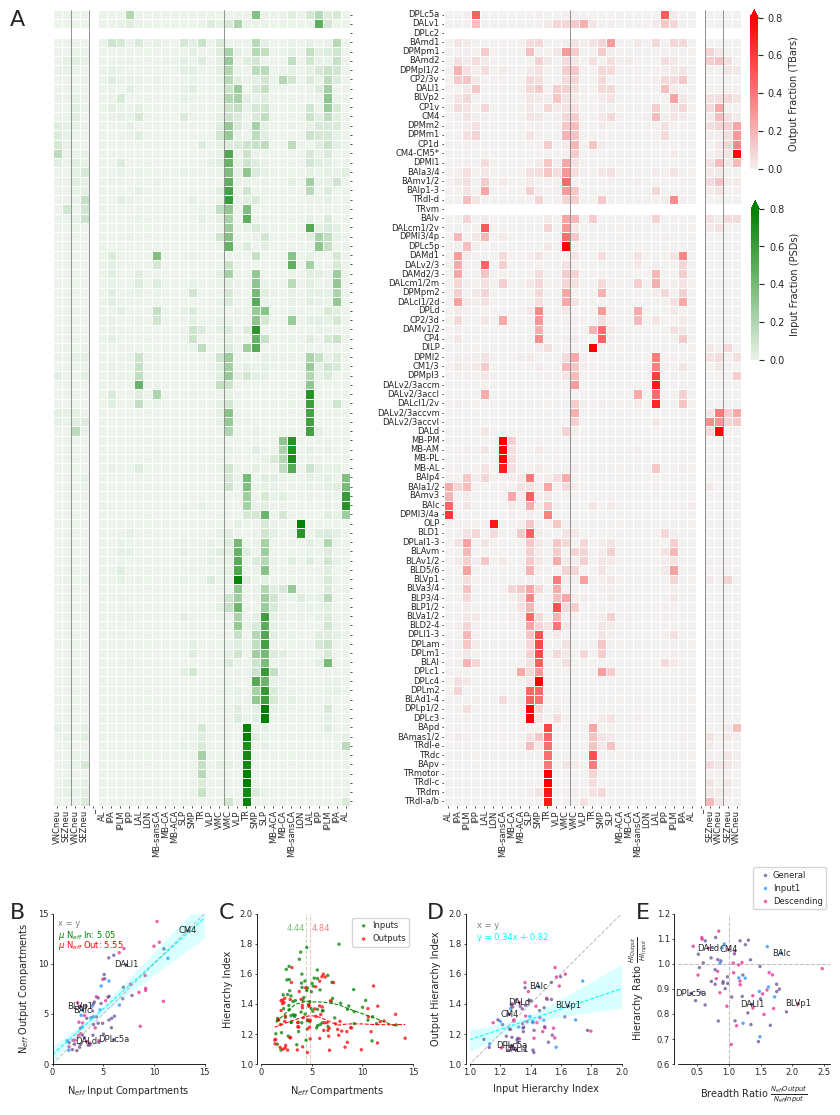

In [9]:
width  = 8.5
height = 11
fig = plt.figure(figsize = (width, height))
gs  = fig.add_gridspec(42, 32,
                      left = 0.1 / width, right = 1 - (0.1 / width),
                      bottom = 0.1 / height, top = 1 - (0.1 / height))

# ────────────────────────────────────────────────
# Create all axes
# ────────────────────────────────────────────────
# ROW 1
ax_a = fig.add_subplot(gs[1:32, 1:15])
ax_b = fig.add_subplot(gs[1:32, 16:30])

# ROW 2
ax_c = fig.add_subplot(gs[36:42, 1:7])
ax_d = fig.add_subplot(gs[36:42, 9:15])
ax_e = fig.add_subplot(gs[36:42, 17:23])
ax_f = fig.add_subplot(gs[36:42, 25:31])

#────────────────────────────────────────────────
# Adjustment
ax = [ax_a, ax_b, ax_c, ax_d,
      ax_e, ax_f]

for a in ax:
    a.grid(False)
    for s in a.spines.values():
        s.set_color("black")
        s.set_linewidth(0.6)
        s.set_visible(True)
        
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 1.5,
        width     = 0.5,
        pad       = 1.5)
    
#────────────────────────────────────────────────
# Input Heatmap
sns.heatmap(psd_matrix,
			cmap = sns.light_palette("green", as_cmap = True),
            vmin = vmin,
            vmax = vmax,
            ax = ax_a,
			square = False,
            cbar = True,
            cbar_kws = {"label"  : "Fractional Contribution",
                        "extend" : "max",
						"shrink" : 0.2,
						"aspect" : 20,
						"pad"    : 0.025,
						"anchor" : (8.5, 0.7)},
			linewidths  = 0.5,
			xticklabels = True,
			yticklabels = True,
			)

# Output Heatmap
sns.heatmap(tbar_matrix,
			cmap   = sns.light_palette("red", as_cmap = True),
            vmin = vmin,
            vmax = vmax,
            ax = ax_b,
			square = False,
            cbar = True,
			cbar_kws = {"label"  : "Fractional Contribution",
                        "extend" : "max",
						"shrink" : 0.2,
						"aspect" : 20,
						"pad"    : 0.025,
						"anchor" : (0, 1)},
			linewidths  = 0.5,
			xticklabels = True,
			yticklabels = True,
			)
# Label Cleanup
# Only Y labels removed for Right plot
ax_b.set_ylabel("")

# All Y ticks for Left plot
ax_a.yaxis.tick_right()
ax_a.set_yticklabels([])
ax_a.set_ylabel("")

# Compartment Labels to be updated
ax_a.invert_xaxis()

# Measures
meas = ["Input Fraction (PSDs)", "Output Fraction (TBars)"]
for i, a in enumerate([ax_a, ax_b]):
    # Change the CBar
    cbar = a.collections[0].colorbar
    cbar.set_label(meas[i], size = label_fontsize)
    cbar.ax.tick_params(labelsize = label_fontsize)
    # Update the ticks
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 1.5,
        width     = 0.5,
        pad       = 1.5)

    # Remove the X-label
    a.set_xlabel("")
    # Update the bottom xticks to remove the Ipsi and Contra
    new_labels  = [label.get_text().replace("_Ipsi", "").replace("_Contra", "") for label in a.get_xticklabels()]
    # Re-apply
    a.set_xticks(a.get_xticks())
    a.set_xticklabels(new_labels)

    # Division Lines
    a.axvline(x = 14, color = "black", linewidth = 0.5, alpha = 0.6)
    a.axvline(x = 29, color = "black", linewidth = 0.5, alpha = 0.6)
    a.axvline(x = 31, color = "black", linewidth = 0.5, alpha = 0.6)

#────────────────────────────────────────────────
# Metrics 
# Shanneon Neff
# Best Fit Line
ax_c.set_xlim(0, 15)
ax_c.set_ylim(0, 15)

sns.scatterplot(data  = focusness_df,
                x     = "PSDs_Entropy_Neff",
                y     = "TBars_Entropy_Neff",
                ax    = ax_c,
                alpha = scatter_alpha,
                hue   = "Direction",
                palette = palette,
                legend = False,
                s      = scatter_size,
                edgecolor = "none")


sns.regplot(data = focusness_df,
            x = "PSDs_Entropy_Neff",
            y = "TBars_Entropy_Neff",
            ax = ax_c,
            scatter = False,
            line_kws = {"color": "cyan", "linewidth" : linewidth, "linestyle": "--"},
            truncate = False)

# Place means
mean_in = np.mean(focusness_df["PSDs_Entropy_Neff"])
mean_out = np.mean(focusness_df["TBars_Entropy_Neff"])
             
# Limits and labels
ax_c.set_xlabel("N$_{eff}$ Input Compartments", labelpad = 5, fontsize = label_fontsize)
ax_c.set_ylabel("N$_{eff}$ Output Compartments", labelpad = 5, fontsize = label_fontsize)
ax_c.set_xticks([0, 5, 10, 15])
ax_c.set_yticks([0, 5, 10, 15])

# Add x = y
ax_c.plot([0, 20], [0, 20], linestyle = "--",
          color = "grey", linewidth = linewidth,
          alpha = 0.5)
ax_c.text(0.5, 14.5, "x = y", fontsize = tick_fontsize,
          ha = "left", va = "top", color = "grey")
ax_c.text(0.5, 13.5, f"$\mu$ N$_{{eff}}$ In: {mean_in:.2f}", fontsize = tick_fontsize,
          ha = "left", va = "top", color = "green")
ax_c.text(0.5, 12.5, f"$\mu$ N$_{{eff}}$ Out: {mean_out:.2f}", fontsize = tick_fontsize,
          ha = "left", va = "top", color = "red")

# Names
name_plotter(ax_c, "PSDs_Entropy_Neff", "TBars_Entropy_Neff")

#----------------------------------------
# Breadth vs Hierarchy
# Limits and labels
ax_d.set_xlim(0, 15)
ax_d.set_ylim(1, 2)
sns.regplot(data = focusness_df,
            x = "PSDs_Entropy_Neff",
            y = "PSDs_Hierarchy",
            ax = ax_d,
            scatter_kws = {"alpha": scatter_alpha, "color": "green", "s" : scatter_size, "edgecolor" : "none"},
            line_kws = {"color": "green", "linewidth" : linewidth, "linestyle": "--"},
            truncate = False,
            lowess = True,
            label = "Inputs")

# Transition Lines
# 1
# Get the lowess line and find the transition point
line_data = ax_d.get_lines()[0].get_data()
x_lowess = line_data[0]
y_lowess = line_data[1]

# Calculate the "Slope" (First Derivative)
dy = np.diff(y_lowess)
dx = np.diff(x_lowess)
slopes = dy / dx

# Find where the slope "flattens" (e.g., drops below 0.01)
# We find the first index where the slope is no longer strongly positive
transition_point = np.where(slopes <= 0)[0][0]
transition_val   = x_lowess[transition_point]

# Line
ax_d.axvline(x = transition_val, color = "green", linestyle = "--", linewidth = linewidth, alpha = 0.25)
ax_d.text(transition_val - 0.15, 1.9, f"{transition_val:.2f}", fontsize = tick_fontsize,
          ha = "right", va = "center", color = "green", alpha = 0.5)

sns.regplot(data = focusness_df,
            x = "TBars_Entropy_Neff",
            y = "TBars_Hierarchy",
            ax = ax_d,
            scatter_kws = {"alpha": scatter_alpha, "color": "red", "s" : scatter_size, "edgecolor" : "none"},
            line_kws = {"color": "red", "linewidth" : linewidth, "linestyle": "--"},
            truncate = False,
            lowess = True,
            label = "Outputs")

# 2
# Get the lowess line and find the transition point
line_data = ax_d.get_lines()[-1].get_data()

x_lowess = line_data[0]
y_lowess = line_data[1]

# Calculate the "Slope" (First Derivative)
dy = np.diff(y_lowess)
dx = np.diff(x_lowess)
slopes = dy / dx

# Find where the slope "flattens" (e.g., drops below 0.01)
# We find the first index where the slope is no longer strongly positive
transition_point = np.where(slopes <= 0)[0][0]
transition_val   = x_lowess[transition_point]

# Line
ax_d.axvline(x = transition_val, color = "red", linestyle = "--", linewidth = linewidth, alpha = 0.25)
ax_d.text(transition_val + 0.15, 1.9, f"{transition_val:.2f}", fontsize = tick_fontsize,
          ha = "left", va = "center", color = "red", alpha = 0.5)

# Labels
ax_d.set_xlabel("N$_{eff}$ Compartments", labelpad = 5, fontsize = label_fontsize)
ax_d.set_ylabel("Hierarchy Index", labelpad = 5, fontsize = label_fontsize)
ax_d.set_xticks([0, 5, 10, 15])
ax_d.legend(loc = "upper right", bbox_to_anchor = (1, 1),
            fontsize = tick_fontsize,
            handletextpad = 0.01)

#----------------------------------------
# Hierarchy input vs output
# Limits and labels
ax_e.set_xlim(1, 2)
ax_e.set_ylim(1, 2)
sns.scatterplot(data  = focusness_df,
                x     = "PSDs_Hierarchy",
                y     = "TBars_Hierarchy",
                ax    = ax_e,
                alpha = scatter_alpha,
                hue   = "Direction",
                palette = palette,
                legend = False,
                s      = scatter_size,
                edgecolor = "none")

sns.regplot(data = focusness_df,
            x = "PSDs_Hierarchy",
            y = "TBars_Hierarchy",
            ax = ax_e,
            scatter = False,
            line_kws = {"color": "cyan", "linewidth" : linewidth, "linestyle": "--"},
            truncate = False)


empty = focusness_df["TBars_Hierarchy"].isna() | focusness_df["PSDs_Hierarchy"].isna()
slope, intercept, r_val, p_val, stderr = linregress(
    focusness_df["PSDs_Hierarchy"][~empty],
    focusness_df["TBars_Hierarchy"][~empty]
    )

ax_e.set_xlabel("Input Hierarchy Index", labelpad = 5, fontsize = label_fontsize)
ax_e.set_ylabel("Output Hierarchy Index", labelpad = 5, fontsize = label_fontsize)

# Add x = y
ax_e.plot([0, 3], [0, 3], linestyle = "--",
          color = "grey", linewidth = linewidth,
          alpha = 0.5)
ax_e.text(1.05, 1.95, "x = y", fontsize = tick_fontsize,
          ha = "left", va = "top", color = "grey")
ax_e.text(1.05, 1.87, f"y = {slope:.2f}x + {intercept:.2f}", fontsize = tick_fontsize,
          ha = "left", va = "top", color = "cyan")

# # Names
name_plotter(ax_e, "PSDs_Hierarchy", "TBars_Hierarchy")

#----------------------------------------
# Ratios
sns.scatterplot(data  = focusness_df,
                x     = "Breadth_Ratio",
                y     = "Hierarchy_Ratio",
                ax    = ax_f,
                alpha = scatter_alpha,
                hue   = "Direction",
                palette = palette,
                legend = True,
                s      = scatter_size,
                edgecolor = "none")

# Legend
ax_f.legend(loc = "lower right", bbox_to_anchor = (1, 1),
            fontsize = tick_fontsize, ncols = 1,
            handletextpad = 0.01)
# Lines
ax_f.axhline(y = 1, color = "grey", linestyle = "--", linewidth = linewidth, alpha = 0.5)
ax_f.axvline(x = 1, color = "grey", linestyle = "--", linewidth = linewidth, alpha = 0.5)

# Limits and labels
ax_f.set_xlim(0.2, 2.6)
ax_f.set_ylim(0.6, 1.2)
ax_f.set_xlabel(r"Breadth Ratio $\frac{N_{eff} Output}{N_{eff} Input}$", labelpad = 5, fontsize = label_fontsize)
ax_f.set_ylabel(r"Hierarchy Ratio $\frac{HI_{Output}}{HI_{Input}}$", labelpad = 5, fontsize = label_fontsize)

# # Names
name_plotter(ax_f, "Breadth_Ratio", "Hierarchy_Ratio")

#----------------------------------------
# Despine
for a in [ax_c, ax_d, ax_e, ax_f]:
    sns.despine(ax = a)

# Offset
for a in [ax_d, ax_e, ax_f]:
    sns.despine(ax = a, offset = {"left" : 3})

#--------------------------------------------------------
# Panel Labels
place_panel_label(fig, ax_a, "A", shx = -0.05, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax_c, "B", shx = -0.05, shy = 0.01, label_kwargs = label_kwargs)
place_panel_label(fig, ax_d, "C", shx = -0.05, shy = 0.01, label_kwargs = label_kwargs)
place_panel_label(fig, ax_e, "D", shx = -0.05, shy = 0.01, label_kwargs = label_kwargs)
place_panel_label(fig, ax_f, "E", shx = -0.05, shy = 0.01, label_kwargs = label_kwargs)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_03.pdf",
            dpi = 1200,
            bbox_inches = "tight")

## Supplementary 01 : Thresholded Innervation

In [10]:
# Store the counts
tbar_counts = []
steps = np.linspace(0, 1, 2000)
# Loop over each threshold
for i in steps:
    thresholded = np.sum(tbar_matrix > i, axis = 1)
    tbar_counts.append(np.mean(thresholded.values))

# Store the counts
psds_counts = []
# Loop over each threshold
for i in steps:
    thresholded = np.sum(psd_matrix > i, axis = 1)
    psds_counts.append(np.mean(thresholded.values))

Setting threshold to 3% (for match)

In [11]:
thresh = 0.03

# Which step 
cross = np.where(steps >= thresh)[0][0]
out_cross = tbar_counts[cross]
in_cross  = psds_counts[cross]

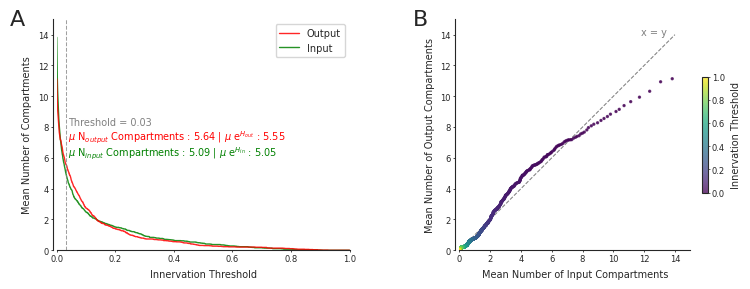

In [12]:
width  = 8.5
height = 3
fig, ax = plt.subplots(figsize = (width, height),
                   ncols = 2)
plt.subplots_adjust(wspace = 0.25)

#----------------------------------------
# Plotting the thresholded number of compartments
ax[0].plot(steps, tbar_counts,
           color = "red",
           alpha = 0.85,
           linewidth = 1,
           label = "Output",
           zorder = 1)

ax[0].plot(steps, psds_counts,
           color = "green",
           alpha = 0.85,
           linewidth = 1,
           label = "Input",
           zorder = 0)

# Labels
ax[0].set_xlabel("Innervation Threshold", fontsize = label_fontsize)
ax[0].set_ylabel("Mean Number of Compartments", fontsize = label_fontsize)

# Legend
ax[0].legend(fontsize = label_fontsize)

# Limits
ax[0].set_xlim([0, 1])
ax[0].set_ylim([0, 15])

# Vertical Line at 3% threshold
ax[0].axvline(x = thresh,
              color = "grey",
              alpha = 0.75,
              linewidth = linewidth,
              linestyle = "--")
ax[0].text(0.04, out_cross + 2.5,
           "Threshold = 0.03",
           color = "grey",
           fontsize = label_fontsize)

# Placing the pointed to the number of compartments at the cross point
ax[0].text(0.04, out_cross + 1.5,
           f"$\mu$ N$_{{output}}$ Compartments : {out_cross:.2f} | $\mu$ e$^{{H_{{out}}}}$ : {mean_out:.2f}",
           color = "red",
           fontsize = label_fontsize)

ax[0].text(0.04, in_cross + 1,
           f"$\mu$ N$_{{input}}$ Compartments : {in_cross:.2f} | $\mu$ e$^{{H_{{in}}}}$ : {mean_in:.2f}",
           color = "green",
           fontsize = label_fontsize)
           
#----------------------------------------
# Matching mean input output ratio
scatter = ax[1].scatter(psds_counts, tbar_counts,
                     c = steps, cmap = 'viridis',
                     alpha = 0.75, s = 2)
ax[1].set_aspect("equal")
# Limits
ax[1].set_xlim(0, 15)
ax[1].set_ylim(0, 15)

# Ticks
ticks = np.linspace(0, 14, 8)
labels = ticks.astype(int)
ax[1].set_xticks(ticks, labels)
ax[1].set_yticks(ticks, labels)

# x = y
ax[1].plot(ticks, ticks, color = "grey", linestyle = "--",
        linewidth = linewidth, zorder = 0)
ax[1].text(13.5, 14.5,
           "x = y",
           color = "grey",
           ha = "right", va = "top",
           fontsize = label_fontsize)

# Labels
ax[1].set_xlabel("Mean Number of Input Compartments", fontsize = label_fontsize)
ax[1].set_ylabel("Mean Number of Output Compartments", fontsize = label_fontsize)

#----------------------------------------
for i, a in enumerate(ax):
    # Change the CBar
    # Update the ticks
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 1.5,
        width     = 0.5,
        pad       = 1.5)
    # Despine
    sns.despine(ax = a)

cbar = fig.colorbar(
    scatter,
    ax       = ax[1],
    shrink   = 0.5,
    fraction = 0.046,   # size relative to axis
    pad      = 0.04          # spacing from axis
)

cbar.set_label(
    "Innervation Threshold",
    fontsize=label_fontsize
)

cbar.ax.tick_params(
    labelsize = tick_fontsize,
    length    = 1.5,
    width     = 0.5,
    pad       = 1.5)

# Panel Labels
# Add extra offsets
for a in ax:
    sns.despine(ax = a, offset = {"left" : 3})
label_kwargs["va"] = "center"
place_panel_label(fig, ax[0], "A", shx = -0.055, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax[1], "B", shx = -0.055, shy = 0, label_kwargs = label_kwargs)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_03_Supplementary-01_Innervation-Threshold.pdf",
            dpi = 1200,
            bbox_inches = "tight")

## Supplementary 02 : Focusness in Dendrites

In [13]:
# Inputs
psd_dendrite_matrix = pd.read_parquet(f"{DATA}/Lineage_Innervation_Dendrites-PSDs_level1.parquet")
psd_dendrite_matrix.set_index("Lineage", inplace = True)
psd_dendrite_matrix = psd_dendrite_matrix.reindex(columns = comp_order)

In [14]:
dendrite_focusness_df = pd.read_parquet(f"{DATA}/Lineage_Focusness_level1_Dendrites.parquet")

# Merge this as direction
dendrite_focusness_df["Direction"] = np.select(
    condlist =[
        dendrite_focusness_df["Lineage"].isin(desc_lineages),
        dendrite_focusness_df["Lineage"].isin(in2_lineages),
    ],
    choicelist = [
        "Descending",
        "Input1",
    ],
    default = "General"
)

Comparing the Focusness between Neuron and Dendrite Alone

In [15]:
# Copy and keep the dendritic part
lineage_focus = dendrite_focusness_df.copy()
lineage_focus = lineage_focus[["Lineage", "PSDs_Entropy_Neff"]]
lineage_focus.rename(columns = {"PSDs_Entropy_Neff" : "Dendrite_PSDs_Entropy_Neff"},
                     inplace = True)

# Merge with Lineage
lineage_focus = pd.merge(lineage_focus, focusness_df[["Lineage", "PSDs_Entropy_Neff", "Direction"]],
                         on = "Lineage", how = "left")

# Delta
lineage_focus["Delta"] = lineage_focus["PSDs_Entropy_Neff"] - lineage_focus["Dendrite_PSDs_Entropy_Neff"]

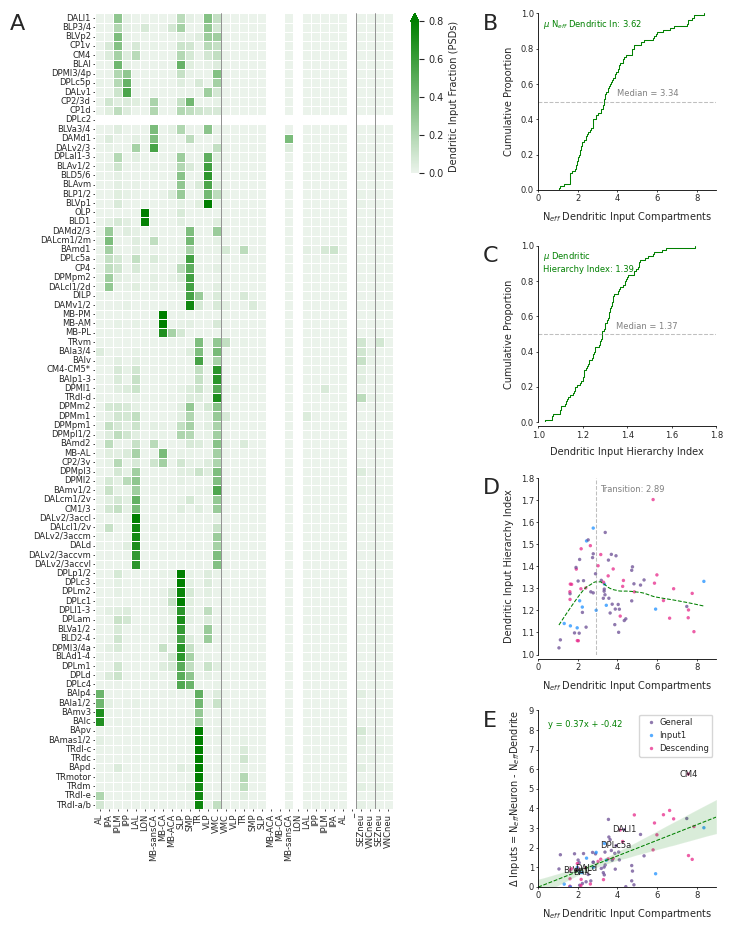

In [16]:
width  = 8.5
height = 11
fig = plt.figure(figsize = (width, height))
gs  = fig.add_gridspec(42, 32,
                      left = 0.1 / width, right = 1 - (0.1 / width),
                      bottom = 0.1 / height, top = 1 - (0.1 / height))

# ────────────────────────────────────────────────
# Create all axes
# ────────────────────────────────────────────────
# COL 1
ax_a = fig.add_subplot(gs[1:32, 1:15])

# COL 2
ax_b = fig.add_subplot(gs[1:8, 18:25]) # Schematic
ax_c = fig.add_subplot(gs[10:17, 18:25])
ax_d = fig.add_subplot(gs[19:26, 18:25])
ax_e = fig.add_subplot(gs[28:35, 18:25])

#────────────────────────────────────────────────
# Adjustment
ax = [ax_a, ax_b, ax_c, ax_d,
      ax_e]

for a in ax:
    a.grid(False)
    for s in a.spines.values():
        s.set_color("black")
        s.set_linewidth(0.6)
        s.set_visible(True)
        
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 1.5,
        width     = 0.5,
        pad       = 1.5)
    
#────────────────────────────────────────────────
# Input Heatmap
sns.heatmap(psd_dendrite_matrix,
			cmap = sns.light_palette("green", as_cmap = True),
            vmin = vmin,
            vmax = vmax,
            ax = ax_a,
			square = False,
            cbar = True,
            cbar_kws = {"label"  : "Dendritic Fractional Contribution",
                        "extend" : "max",
						"shrink" : 0.2,
						"aspect" : 20,
						"pad"    : 0.025,
						"anchor" : (0.2, 1)},
			linewidths  = 0.5,
			xticklabels = True,
			yticklabels = True,
			)


# Remove Label
ax_a.set_ylabel("")

# Division Lines
ax_a.axvline(x = 14, color = "black", linewidth = 0.5, alpha = 0.6)
ax_a.axvline(x = 29, color = "black", linewidth = 0.5, alpha = 0.6)
ax_a.axvline(x = 31, color = "black", linewidth = 0.5, alpha = 0.6)

# Measures
meas = ["Dendritic Input Fraction (PSDs)"]
for i, a in enumerate([ax_a]):
    # Change the CBar
    cbar = a.collections[0].colorbar
    cbar.set_label(meas[i], size = label_fontsize)
    cbar.ax.tick_params(labelsize = label_fontsize)
    # Update the ticks
    a.tick_params(
        axis      = "both",
        which     = "major",
        color     = "black",
        labelsize = tick_fontsize,
        length    = 1.5,
        width     = 0.5,
        pad       = 1.5)

    # Remove the X-label
    a.set_xlabel("")
    # Update the bottom xticks to remove the Ipsi and Contra
    new_labels  = [label.get_text().replace("_Ipsi", "").replace("_Contra", "") for label in a.get_xticklabels()]
    # Re-apply
    a.set_xticks(a.get_xticks())
    a.set_xticklabels(new_labels)

#────────────────────────────────────────────────
# Neff Distribution
sns.ecdfplot(data = dendrite_focusness_df,
             x  = "PSDs_Entropy_Neff",
             ax = ax_b,
             color = "green",
             linewidth = linewidth,
             alpha = 1)

# Limits
ax_b.set_xlim(0, 9)
ax_b.set_ylim(0, 1)
ax_b.set_xlabel("N$_{eff}$ Dendritic Input Compartments", labelpad = 5, fontsize = label_fontsize)
ax_b.set_ylabel("Cumulative Proportion", labelpad = 5, fontsize = label_fontsize)

# Take the mean
mean_neff   = np.mean(dendrite_focusness_df["PSDs_Entropy_Neff"])
median_neff = np.median(dendrite_focusness_df["PSDs_Entropy_Neff"])

# Lines
ax_b.axhline(y = 0.5, color = "grey", linestyle = "--", linewidth = linewidth, alpha = 0.5)
ax_b.text(4, 0.52, f"Median = {median_neff:.2f}", fontsize = tick_fontsize,
          ha = "left", va = "bottom", color = "grey")
ax_b.text(0.25, 0.975, f"$\mu$ N$_{{eff}}$ Dendritic In: {mean_neff:.2f}", fontsize = tick_fontsize,
          ha = "left", va = "top", color = "green")

# Despine
sns.despine(ax = ax_b)

#────────────────────────────────────────────────
# Hierarchy Distribution
sns.ecdfplot(data = dendrite_focusness_df,
            x = "PSDs_Hierarchy",
            ax = ax_c,
            color = "green",
            linewidth = linewidth,
            alpha = 1)

# Limits
ax_c.set_xlim(1, 1.8)
ax_c.set_ylim(0, 1)
ax_c.set_xlabel("Dendritic Input Hierarchy Index", labelpad = 5, fontsize = label_fontsize)
ax_c.set_ylabel("Cumulative Proportion", labelpad = 5, fontsize = label_fontsize)

# Take the mean
mean_hierarchy   = np.mean(focusness_df["PSDs_Hierarchy"])
median_hierarchy = np.median(focusness_df["PSDs_Hierarchy"])

# Lines
ax_c.axhline(y = 0.5, color = "grey", linestyle = "--", linewidth = linewidth, alpha = 0.5)
ax_c.text(1.35, 0.52, f"Median = {median_hierarchy:.2f}", fontsize = tick_fontsize,
          ha = "left", va = "bottom", color = "grey")
ax_c.text(1.02, 0.975, f"$\mu$ Dendritic\nHierarchy Index: {mean_hierarchy:.2f}", fontsize = tick_fontsize,
          ha = "left", va = "top", color = "green")

# Despine
sns.despine(ax = ax_c)

#────────────────────────────────────────────────
# Neff vs Hierarchy
# Limits
ax_d.set_xlim(0, 9)
ax_d.set_ylim(1, 1.8)

sns.scatterplot(data  = dendrite_focusness_df,
                x     = "PSDs_Entropy_Neff",
                y     = "PSDs_Hierarchy",
                ax    = ax_d,
                alpha = scatter_alpha,
                hue   = "Direction",
                palette = palette,
                legend = False,
                s      = scatter_size,
                edgecolor = "none")

sns.regplot(data = dendrite_focusness_df,
                x = "PSDs_Entropy_Neff",
                y = "PSDs_Hierarchy",
                ax = ax_d,
                scatter = False,
                line_kws = {"color": "green", "linewidth" : linewidth, "linestyle": "--"},
                truncate = False,
                lowess = True)


ax_d.set_ylabel("Dendritic Input Hierarchy Index", labelpad = 5, fontsize = label_fontsize)
ax_d.set_xlabel("N$_{eff}$ Dendritic Input Compartments", labelpad = 5, fontsize = label_fontsize)

# Get the lowess line and find the transition point
line_data = ax_d.get_lines()[0].get_data()
x_lowess = line_data[0]
y_lowess = line_data[1]

# Slope
dy = np.diff(y_lowess)
dx = np.diff(x_lowess)
slopes = dy / dx

# Flatness point
# We find the first index where the slope is no longer strongly positive
transition_point = np.where(slopes <= 0)[0][0]
transition_val   = x_lowess[transition_point]

# Transition Line
ax_d.axvline(x = transition_val, color = "grey", linestyle = "--", linewidth = linewidth, alpha = 0.5)
ax_d.text(3.1, 1.75, f"Transition: {transition_val:.2f}", fontsize = tick_fontsize,
          ha = "left", va = "center", color = "grey")

# Name 
# name_plotter(ax_d, "PSDs_Entropy_Neff", "PSDs_Hierarchy", df = dendrite_focusness_df)

# Despine
sns.despine(ax = ax_d)

#────────────────────────────────────────────────
# Dendrite vs Neuron
ax_e.set_xlim(0, 9)
ax_e.set_ylim(0, 9)

sns.scatterplot(data  = lineage_focus,
                x     = "Dendrite_PSDs_Entropy_Neff",
                y     = "Delta",
                ax    = ax_e,
                alpha = scatter_alpha,
                hue   = "Direction",
                palette = palette,
                legend = True,
                s      = scatter_size,
                edgecolor = "none")

sns.regplot(data = lineage_focus,
                x = "Dendrite_PSDs_Entropy_Neff",
                y = "Delta",
                ax = ax_e,
                scatter = False,
                # scatter_kws = {"alpha": scatter_alpha, "color": "green", "s" : scatter_size, "edgecolor" : "none"},
                line_kws = {"color": "green", "linewidth" : linewidth, "linestyle": "--"},
                truncate = False,
                lowess = False)

# Legend
ax_e.legend(loc = "upper right", bbox_to_anchor = (1, 1),
            fontsize = tick_fontsize,
            handletextpad = 0.01)

# Fit Line
slope, intercept, r_val, p_val, stderr = linregress(
    lineage_focus["PSDs_Entropy_Neff"].dropna(),
    lineage_focus["Delta"].dropna())

# Name 
name_plotter(ax_e, "Dendrite_PSDs_Entropy_Neff", "Delta",
            df = lineage_focus.loc[lineage_focus["Lineage"].isin(lineages_to_show)])

# Line Label
ax_e.text(0.5, 8.5, f"y = {slope:.2f}x + {intercept:.2f}", fontsize = tick_fontsize,
          ha = "left", va = "top", color = "green")

# Labels
ax_e.set_ylabel("$\Delta$ Inputs = N$_{eff}$Neuron - N$_{eff}$Dendrite", labelpad = 5, fontsize = label_fontsize)
ax_e.set_xlabel("N$_{eff}$ Dendritic Input Compartments", labelpad = 5, fontsize = label_fontsize)

# Despine
sns.despine(ax = ax_e)

#--------------------------------------------------------
# Extra Offsets
for a in [ax_c, ax_d]:
    sns.despine(ax = a, offset = {"bottom" : 3})

#--------------------------------------------------------
# Panel Labels
label_kwargs["va"] = "top"
place_panel_label(fig, ax_a, "A", shx = -0.10, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax_b, "B", shx = -0.065, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax_c, "C", shx = -0.065, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax_d, "D", shx = -0.065, shy = 0, label_kwargs = label_kwargs)
place_panel_label(fig, ax_e, "E", shx = -0.065, shy = 0, label_kwargs = label_kwargs)

#--------------------------------------------------------
# Save the Figure
plt.savefig(f"{FOLDER}/Figure_03_Supplementary-02_Dendrite-Focusness.pdf",
            dpi = 1200,
            bbox_inches = "tight")

# <center>**हो गया दोस्तों!**</center>